In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Transient Detection in Strong Lenses with SBI

Amortized posterior on `transient_flux_frac` using `sbi.NPE` with a CNN embedding net.

- **Training data:** 10K paired clean / anomalous lens images from `data/`.
- **Parameter:** `theta = transient_flux_frac`, with `0` for clean images and the metadata value for anomalous ones.
- **Detection rule:** posterior mass above a small threshold given an observed image.
- **Bonus:** when a transient is detected, the same posterior also estimates its flux.

In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install sbi
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform

DATA_DIR = Path('/content/drive/MyDrive/sbi-data')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'device = {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.8/517.8 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 28.0 MB/s eta 0:00:00
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53654 sha256=daf11385511d4ed084bd6f2aa1523264a19fa8301c8ad57adeef9e78cb36284a
  Stored in directory: /root/.cache/pip/wheels/fd/27/c3/8952205ea17b63dc1eaa24031e63111c6a3661cb22cc1e2a3c
Successfully built nflows
device = cuda


## 1. Load data and build (theta, x) tensors

Each underlying lens system contributes two rows: one clean (theta=0) and one anomalous (theta=metadata flux frac). We split by **lens index** so the paired halves never straddle train/test.

In [3]:
clean = np.load(DATA_DIR / 'clean_images.npy')         # (N, 240, 240)
anom  = np.load(DATA_DIR / 'anomalous_images.npy')      # (N, 240, 240)
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

N = clean.shape[0]
assert anom.shape[0] == N == len(metadata)
flux_frac = np.array([m['transient_flux_frac'] for m in metadata], dtype=np.float32)
print(f'N = {N}, image shape = {clean.shape[1:]}, flux_frac range = [{flux_frac.min():.3f}, {flux_frac.max():.3f}]')

N = 10000, image shape = (240, 240), flux_frac range = [0.050, 0.150]


In [4]:
# Split by lens index so paired clean+anomalous of the same system stay together.
rng = np.random.default_rng(SEED)
perm = rng.permutation(N)
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]
print(f'train/val/test lens systems: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}')

train/val/test lens systems: 8000/1000/1000


In [5]:
STRETCH = 0.01  # ~ background noise scale (NOT the visualization stretch)

def stretch(images):
    return np.arcsinh(images / STRETCH).astype(np.float32)

# Compute global mean/std once on training clean images and reuse on every
# split. Using a single affine transform for both clean and anomalous images
# preserves the additive transient perturbation that distinguishes them.
_train_stretched = stretch(clean[train_idx])
GLOBAL_MEAN = float(_train_stretched.mean())
GLOBAL_STD  = float(_train_stretched.std() + 1e-6)
del _train_stretched
print(f'GLOBAL_MEAN={GLOBAL_MEAN:.4f}, GLOBAL_STD={GLOBAL_STD:.4f}')

def normalize(images):
    return (stretch(images) - GLOBAL_MEAN) / GLOBAL_STD

def build_split(idx):
    """Stack clean (theta=0) and anomalous (theta=flux_frac) for a list of lens indices."""
    x_clean = normalize(clean[idx])
    x_anom  = normalize(anom[idx])
    x = np.concatenate([x_clean, x_anom], axis=0)[:, None]  # (2*len(idx), 1, 240, 240)
    theta = np.concatenate([np.zeros(len(idx), dtype=np.float32), flux_frac[idx]])[:, None]
    return torch.from_numpy(theta), torch.from_numpy(x)

theta_train, x_train = build_split(train_idx)
theta_val,   x_val   = build_split(val_idx)
theta_test,  x_test  = build_split(test_idx)
print(f'x_train {tuple(x_train.shape)}, theta_train {tuple(theta_train.shape)}')

# Sanity check: paired (anom - clean) should have materially non-zero std.
_diff = normalize(anom[train_idx]) - normalize(clean[train_idx])
print(f'paired (anom - clean) std = {_diff.std():.4f}, max |.| = {np.abs(_diff).max():.4f}')
del _diff

GLOBAL_MEAN=0.8404, GLOBAL_STD=1.2885
x_train (16000, 1, 240, 240), theta_train (16000, 1)
paired (anom - clean) std = 0.0812, max |.| = 6.4717


## 2. CNN embedding network

Maps the 240x240 image to a 64-D summary that `sbi` then feeds into the density estimator.

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, c_out)
        self.norm2 = nn.GroupNorm(8, c_out)
        self.pool = nn.AvgPool2d(2)
    def forward(self, x):
        x = F.gelu(self.norm1(self.conv1(x)))
        x = F.gelu(self.norm2(self.conv2(x)))
        return self.pool(x)

class LensEmbedding(nn.Module):
    """240 -> 120 -> 60 -> 30 -> 15 -> 7 -> Flatten -> MLP -> 128

    No global average pooling: the transient is a localized ~5-7 pixel
    feature, and GAP washes it out across the 15x15 feature map. We keep
    spatial structure through one extra ConvBlock and flatten into an MLP.
    """
    def __init__(self, out_dim=128):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(1, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 128),  # 15 -> 7
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.GELU(),
            nn.Linear(256, out_dim),
        )
    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)  # sbi sometimes passes (B, H, W)
        return self.head(self.blocks(x))

embedding_net = LensEmbedding(out_dim=128)
n_params = sum(p.numel() for p in embedding_net.parameters())
print(f'embedding net params: {n_params/1e6:.2f} M')

embedding net params: 2.23 M


## 3. Train NPE

Prior is `BoxUniform(0, 0.15)` so theta=0 is included. The training set already provides matched theta=0 examples (clean images), so the model learns a sharp mode there for non-transient inputs.

In [7]:
# Pretrain the embedding net as a binary clean-vs-anomalous classifier.
# NPE alone gives weak gradients to a deep image embedding (it's "easy" to
# fit the marginal p(theta) and ignore x), so we first force the embedding
# to actually separate the two classes. If this stays near 50% accuracy,
# something is structurally wrong and NPE will not recover.
import time

embedding_net = embedding_net.to(DEVICE)
clf_head = nn.Linear(128, 1).to(DEVICE)

opt = torch.optim.Adam(
    list(embedding_net.parameters()) + list(clf_head.parameters()),
    lr=1e-3,
)

y_train = (theta_train.numpy().ravel() > 0).astype(np.float32)
y_val   = (theta_val.numpy().ravel()   > 0).astype(np.float32)
y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)

PRETRAIN_EPOCHS = 8
BATCH = 128

def iterate(x, y, batch, shuffle):
    n = len(x)
    idx = np.random.permutation(n) if shuffle else np.arange(n)
    for i in range(0, n, batch):
        sl = idx[i:i + batch]
        yield x[sl].to(DEVICE), y[sl].to(DEVICE)

t0 = time.time()
for epoch in range(1, PRETRAIN_EPOCHS + 1):
    embedding_net.train(); clf_head.train()
    tr_loss = tr_correct = tr_n = 0
    for xb, yb in iterate(x_train, y_train_t, BATCH, shuffle=True):
        logits = clf_head(embedding_net(xb)).squeeze(-1)
        loss = F.binary_cross_entropy_with_logits(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tr_loss += loss.item() * len(xb)
        tr_correct += ((logits > 0).float() == yb).sum().item()
        tr_n += len(xb)

    embedding_net.eval(); clf_head.eval()
    va_correct = va_n = 0
    with torch.no_grad():
        for xb, yb in iterate(x_val, y_val_t, BATCH, shuffle=False):
            logits = clf_head(embedding_net(xb)).squeeze(-1)
            va_correct += ((logits > 0).float() == yb).sum().item()
            va_n += len(xb)
    print(
        f'pretrain epoch {epoch:2d} | train_loss={tr_loss/tr_n:.4f} '
        f'| train_acc={tr_correct/tr_n:.3f} | val_acc={va_correct/va_n:.3f} '
        f'| {time.time() - t0:5.1f}s',
        flush=True,
    )

# Quick sanity: embedding distance between paired clean/anom on a val batch.
with torch.no_grad():
    n_pairs = len(val_idx)
    xc = torch.from_numpy(normalize(clean[val_idx[:64]]))[:, None].to(DEVICE)
    xa = torch.from_numpy(normalize(anom[val_idx[:64]]))[:, None].to(DEVICE)
    ec = embedding_net(xc); ea = embedding_net(xa)
    d_pair = (ec - ea).norm(dim=1).mean().item()
    # Random pair distances as a baseline
    perm = torch.randperm(64)
    d_rand = (ec - ea[perm]).norm(dim=1).mean().item()
    print(f'embedding L2: paired clean-anom = {d_pair:.3f} | random = {d_rand:.3f}')

# Drop the classification head; embedding_net keeps its pretrained weights
# and is passed into NPE in the next cell.
del clf_head, opt
embedding_net = embedding_net.cpu()

pretrain epoch  1 | train_loss=0.6997 | train_acc=0.493 | val_acc=0.500 |  10.6s
pretrain epoch  2 | train_loss=0.4926 | train_acc=0.689 | val_acc=0.949 |  19.6s
pretrain epoch  3 | train_loss=0.0834 | train_acc=0.977 | val_acc=0.985 |  28.7s
pretrain epoch  4 | train_loss=0.0535 | train_acc=0.986 | val_acc=0.994 |  37.8s
pretrain epoch  5 | train_loss=0.0409 | train_acc=0.989 | val_acc=0.996 |  46.9s
pretrain epoch  6 | train_loss=0.0328 | train_acc=0.990 | val_acc=0.993 |  55.9s
pretrain epoch  7 | train_loss=0.0315 | train_acc=0.991 | val_acc=0.996 |  65.0s
pretrain epoch  8 | train_loss=0.0320 | train_acc=0.990 | val_acc=0.995 |  74.2s
embedding L2: paired clean-anom = 52.037 | random = 52.084


In [8]:
import time
import warnings

# Silence two harmless sbi warnings:
#   1. per-pixel "extreme outliers" check — sbi runs this regardless of z_score_x.
#   2. device-string normalization (mps:0 -> mps).
warnings.filterwarnings('ignore', message='Data has extreme outliers')
warnings.filterwarnings('ignore', message=".*has device 'mps:0'.*")

prior = BoxUniform(low=torch.tensor([0.0]), high=torch.tensor([0.15]), device=DEVICE)

# z_score_x='none' is critical: we already arcsinh+standardize images in
# arcsinh_normalize(), and sbi's default per-pixel z-scoring would (a) flag
# every bright arc pixel as an outlier and (b) break the spatial structure
# the CNN embedding net relies on.
density_estimator_build = posterior_nn(
    model='nsf',
    embedding_net=embedding_net,
    hidden_features=64,
    num_transforms=5,
    z_score_x='none',
)

inference = NPE(
    prior=prior,
    density_estimator=density_estimator_build,
    device=DEVICE,
    show_progress_bars=False,
)
# Keep the full training set on CPU — sbi streams batches to the GPU itself.
# Pre-moving x_train to CUDA OOMs because append_simulations runs
# torch.quantile(x, dim=0) on the entire (16000, 1, 240, 240) tensor for its
# outlier check, which allocates several full-size scratch copies (~10 GB).
inference = inference.append_simulations(theta_train, x_train, data_device='cpu')

# sbi's built-in progress only prints "Epochs trained: N" — no losses. Patch
# the per-epoch summary hook so we get a live train/val loss line each epoch.
_orig_summarize = inference._summarize_epoch
_t0 = time.time()

def _summarize_and_print(train_loss, val_loss, epoch_start_time, summarization_kwargs):
    _orig_summarize(train_loss, val_loss, epoch_start_time, summarization_kwargs)
    epoch = inference.epoch + 1   # sbi increments self.epoch *after* this call
    best  = inference._best_val_loss
    marker = '  *' if val_loss <= best else ''
    print(
        f'epoch {epoch:3d} | train_loss={train_loss:+.4f} | '
        f'val_loss={val_loss:+.4f} | best={best:+.4f} | '
        f'{time.time() - _t0:6.1f}s{marker}',
        flush=True,
    )

inference._summarize_epoch = _summarize_and_print

density_estimator = inference.train(
    training_batch_size=128,
    learning_rate=5e-4,
    validation_fraction=0.1,
    stop_after_epochs=15,
    max_num_epochs=200,
    show_train_summary=True,
)
posterior = inference.build_posterior(density_estimator)

epoch   1 | train_loss=-2.8993 | val_loss=-3.8332 | best=+inf |   15.0s  *
epoch   2 | train_loss=-2.9949 | val_loss=-2.9873 | best=-3.8332 |   27.6s
epoch   3 | train_loss=-2.5412 | val_loss=-1.8492 | best=-3.8332 |   40.2s
epoch   4 | train_loss=-2.3767 | val_loss=-2.6444 | best=-3.8332 |   52.9s
epoch   5 | train_loss=-3.0761 | val_loss=-3.4980 | best=-3.8332 |   65.4s
epoch   6 | train_loss=-3.0650 | val_loss=-1.9141 | best=-3.8332 |   78.0s
epoch   7 | train_loss=-2.7514 | val_loss=-3.9122 | best=-3.8332 |   90.5s  *
epoch   8 | train_loss=-2.1841 | val_loss=-2.4151 | best=-3.9122 |  103.2s
epoch   9 | train_loss=-2.1645 | val_loss=-2.9506 | best=-3.9122 |  115.7s
epoch  10 | train_loss=-1.9553 | val_loss=-1.4970 | best=-3.9122 |  128.4s
epoch  11 | train_loss=-2.1716 | val_loss=-2.2872 | best=-3.9122 |  141.0s
epoch  12 | train_loss=-1.2887 | val_loss=+0.1690 | best=-3.9122 |  153.7s
epoch  13 | train_loss=-0.8285 | val_loss=-1.8977 | best=-3.9122 |  166.3s
epoch  14 | train_loss

In [9]:
# Persist artifacts so the rest of the notebook can be re-run without retraining.
torch.save(density_estimator.state_dict(), ARTIFACT_DIR / 'density_estimator.pt')
torch.save({'theta_test': theta_test, 'x_test': x_test, 'test_idx': test_idx},
           ARTIFACT_DIR / 'test_split.pt')
print('saved artifacts to', ARTIFACT_DIR)

saved artifacts to artifacts


## 4. Evaluate on the held-out test set

For each test image, draw posterior samples and compute the detection score `P(theta > eps | x)`.

In [10]:
EPS = 0.01      # transient flux threshold
N_SAMPLES = 500

def detection_scores(x_batch):
    scores = np.zeros(len(x_batch), dtype=np.float32)
    medians = np.zeros(len(x_batch), dtype=np.float32)
    for i in range(len(x_batch)):
        x_i = x_batch[i].to(DEVICE)
        samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
        s = samples.detach().cpu().numpy().ravel()
        scores[i]  = float((s > EPS).mean())
        medians[i] = float(np.median(s))
    return scores, medians

scores, medians = detection_scores(x_test)
labels = (theta_test.numpy().ravel() > 0).astype(np.int32)
print(f'mean score (clean) = {scores[labels==0].mean():.3f}  std = {scores[labels==0].std():.3f}')
print(f'mean score (anom)  = {scores[labels==1].mean():.3f}  std = {scores[labels==1].std():.3f}')

# Embedding-net diagnostic: paired vs random L2 distance on the test set.
embedding_net_eval = embedding_net.to(DEVICE).eval()
with torch.no_grad():
    xc = torch.from_numpy(normalize(clean[test_idx[:128]]))[:, None].to(DEVICE)
    xa = torch.from_numpy(normalize(anom[test_idx[:128]]))[:, None].to(DEVICE)
    ec = embedding_net_eval(xc); ea = embedding_net_eval(xa)
    d_pair = (ec - ea).norm(dim=1).mean().item()
    d_rand = (ec - ea[torch.randperm(len(ea))]).norm(dim=1).mean().item()
    print(f'test embedding L2: paired clean-anom = {d_pair:.3f} | random = {d_rand:.3f}')
embedding_net = embedding_net.cpu()

mean score (clean) = 0.284  std = 0.059
mean score (anom)  = 0.471  std = 0.124
test embedding L2: paired clean-anom = 2.312 | random = 2.746


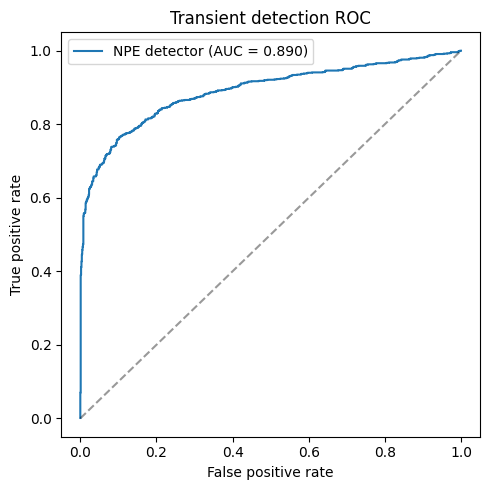

In [11]:
# ROC curve (no sklearn dependency).
def roc_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    tpr = tps / max(y_true.sum(), 1)
    fpr = fps / max((1 - y_true).sum(), 1)
    auc = float(np.trapezoid(tpr, fpr))
    return fpr, tpr, auc

fpr, tpr, auc = roc_curve(labels, scores)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'NPE detector (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Transient detection ROC')
plt.legend()
plt.tight_layout()
plt.show()

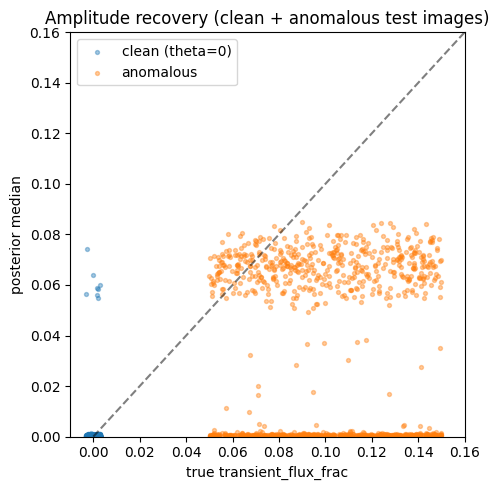

In [16]:
# Amplitude recovery: posterior median vs true flux frac, clean + anomalous.
true_anom = theta_test.numpy().ravel()[labels == 1]
pred_anom = medians[labels == 1]
pred_clean = medians[labels == 0]

# Jitter clean points horizontally around x=0 so overlapping markers are visible.
_jitter_rng = np.random.default_rng(SEED)
jitter_clean = _jitter_rng.uniform(-0.003, 0.003, size=len(pred_clean))

plt.figure(figsize=(5, 5))
plt.scatter(jitter_clean, pred_clean, s=8, alpha=0.4,
            color='tab:blue', label='clean (theta=0)')
plt.scatter(true_anom, pred_anom, s=8, alpha=0.4,
            color='tab:orange', label='anomalous')
lim = [0, 0.16]
plt.plot(lim, lim, 'k--', alpha=0.5)
plt.xlim(-0.01, 0.16); plt.ylim(lim)
plt.xlabel('true transient_flux_frac')
plt.ylabel('posterior median')
plt.title('Amplitude recovery (clean + anomalous test images)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5. Calibration on the with-transient subset

Simulation-based calibration: for each anomalous test image, look at the rank of the true theta inside posterior samples. A trustworthy posterior gives a flat rank histogram.

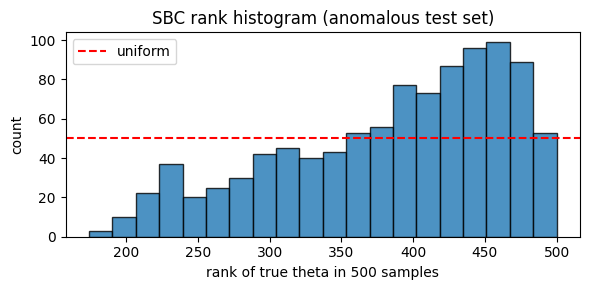

In [13]:
anom_x = x_test[labels == 1]
anom_theta = theta_test[labels == 1].numpy().ravel()

ranks = np.zeros(len(anom_x), dtype=np.int32)
for i in range(len(anom_x)):
    x_i = anom_x[i].to(DEVICE)
    samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
    s = samples.detach().cpu().numpy().ravel()
    ranks[i] = int((s < anom_theta[i]).sum())

plt.figure(figsize=(6, 3))
plt.hist(ranks, bins=20, edgecolor='k', alpha=0.8)
plt.axhline(len(anom_x) / 20, color='r', linestyle='--', label='uniform')
plt.xlabel(f'rank of true theta in {N_SAMPLES} samples')
plt.ylabel('count')
plt.title('SBC rank histogram (anomalous test set)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Failure mode inspection

Look at the worst 5 false positives and 5 false negatives at a 0.5 score cutoff.

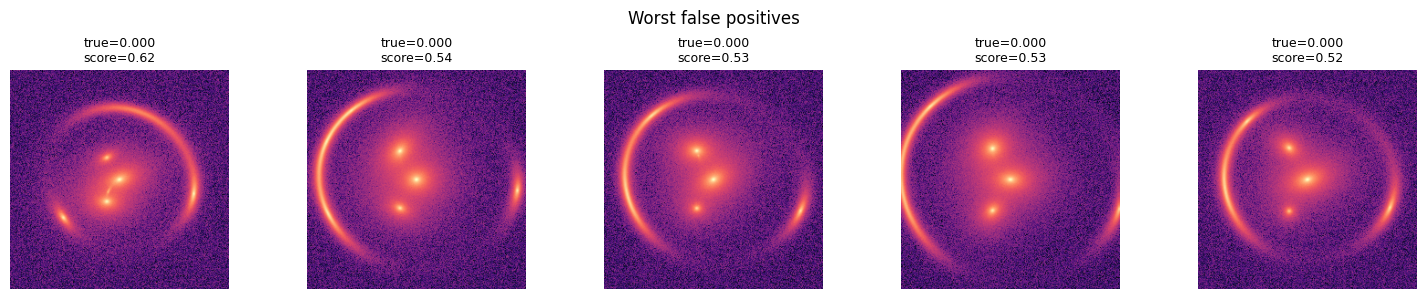

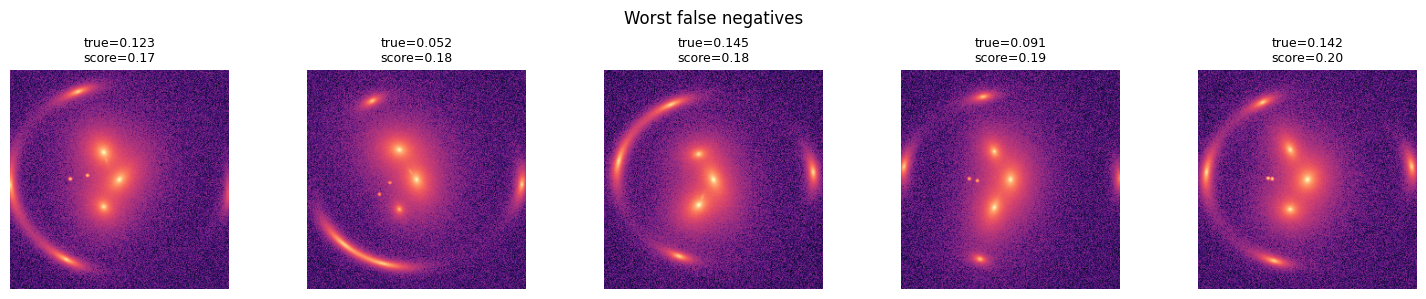

In [15]:
def show_examples(image_indices, title):
    fig, axes = plt.subplots(1, len(image_indices), figsize=(3 * len(image_indices), 3))
    for ax, i in zip(np.atleast_1d(axes), image_indices):
        ax.imshow(x_test[i, 0].numpy(), origin='lower', cmap='magma')
        ax.set_title(f'true={theta_test[i].item():.3f}\nscore={scores[i]:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

fp_idx = np.where((labels == 0) & (scores > 0.5))[0]
fn_idx = np.where((labels == 1) & (scores < 0.5))[0]
fp_idx = fp_idx[np.argsort(-scores[fp_idx])][:5]
fn_idx = fn_idx[np.argsort(scores[fn_idx])][:5]
if len(fp_idx):
    show_examples(fp_idx, 'Worst false positives')
if len(fn_idx):
    show_examples(fn_idx, 'Worst false negatives')